In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gt = pd.read_excel('../../data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt

,contig_name,ground_truth,category_old,category
0,k119_47794_flag_1_multi_143.0000_len_5109_SRR5...,0,5,oth2
1,k141_112743_flag_1_multi_2.0000_len_612_SRR728...,1,1,tob1
2,k141_1210_flag_1_multi_2.0000_len_787_SRR1784304,1,2,tob2
3,k141_12174_flag_1_multi_7.0000_len_1106_SRR178...,1,2,tob2
4,k141_135785_flag_1_multi_5.0000_len_1201_SRR72...,1,1,tob1
...,...,...,...,...
505,NODE_9562_length_2589_cov_93.538279_SRR769314,0,5,oth2
506,NODE_9608_length_2629_cov_6.756270_SRR10143187,0,3,oth1
507,NODE_9819_length_675_cov_2.186131_SRR12904122,1,1,tob1
508,NODE_9835_length_2717_cov_4.322727_SRR10255703,0,5,oth2


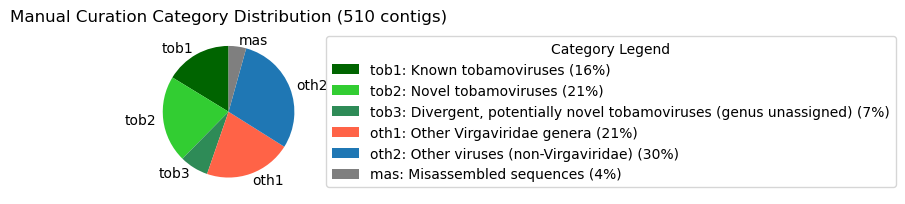

In [3]:
# Prepare value counts (including NaN as a category), ordered tobamoviral -> other
category_order = ["tob1", "tob2", "tob3", "oth1", "oth2", "mas"]
category_counts = gt['category'].value_counts(dropna=False)
if category_counts.index.hasnans:
    category_order.append(float('nan'))
category_counts = category_counts.reindex(category_order)
total = category_counts.sum()

# Define the category palette (green shades = tobamoviral, by descending confidence)
category_palette = {
    "tob1": "#006400",   # dark green - known tobamoviruses
    "tob2": "#32CD32",   # lime green - novel tobamoviruses
    "tob3": "#2E8B57",   # sea green - divergent, potentially novel tobamoviruses
    "oth1": "#FF6347",   # tomato - other Virgaviridae genera
    "oth2": "#1f77b4",   # blue - other viruses, non-Virgaviridae
    "mas": "#7f7f7f",    # grey - misassembled sequences
}

# Category descriptions, from manual_curation_annotation/README.md
category_map = {
    "tob1": "Known tobamoviruses",
    "tob2": "Novel tobamoviruses",
    "tob3": "Divergent, potentially novel tobamoviruses (genus unassigned)",
    "oth1": "Other Virgaviridae genera",
    "oth2": "Other viruses (non-Virgaviridae)",
    "mas": "Misassembled sequences",
}

colors = [category_palette.get(cat, '#cccccc') if pd.notna(cat) else '#cccccc' for cat in category_counts.index]
labels = [cat if pd.notna(cat) else "NaN" for cat in category_counts.index]

# Pie plot with only category codes as labels (no percentages)
plt.figure(figsize=(8, 8))
wedges, texts = plt.pie(
    category_counts,
    labels=labels,
    colors=colors,
    startangle=90,
    labeldistance=1.1
)

# Build legend labels with percentages (rounded to integer)
legend_labels = []
for cat in category_counts.index:
    count = category_counts[cat]
    percent = round(100 * count / total)
    if pd.isna(cat):
        legend_labels.append(f"NaN: missing category ({percent}%)")
    else:
        legend_labels.append(f"{cat}: {category_map.get(cat, 'Unknown')} ({percent}%)")

plt.legend(wedges, legend_labels, title="Category Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Manual Curation Category Distribution (510 contigs)')
plt.tight_layout()
plt.show()